In [1]:
!pip install geopandas duckdb -q

In [2]:
import pathlib

# Sperate raw data from clean data to prevent overwriting. #
for folder in ["Raw Data", "Processed Data", "Outputs"]:
    pathlib.Path(folder).mkdir(parents=True, exist_ok=True)

print("Ready")

Ready


In [3]:
import pandas as pd
import geopandas as gpd
import requests, io
from pathlib import Path

RAW = Path("Raw Data")

# The Chicago Data Portal runs Socrata. When you pull data from it, you only get the first 1,000 rows by default. #
LIMIT = 500_000
def csv_url(ds): return f"https://data.cityofchicago.org/resource/{ds}.csv?$limit={LIMIT}"
def geo_url(ds): return f"https://data.cityofchicago.org/api/geospatial/{ds}?method=export&format=GeoJSON"

# Direct URL reads can reduce part of the file, must download it fully before analyzing. #
def get_geojson(ds):
    for url in [f"https://data.cityofchicago.org/resource/{ds}.geojson?$limit=100000", geo_url(ds)]:
        try:
            r = requests.get(url, timeout=120); r.raise_for_status()
            return gpd.read_file(io.BytesIO(r.content))
        except Exception as e:
            last = e
    raise last

print("Ready")

Ready


In [4]:
# How a neighborhood's hardhip will be evaluated. #
hardship = pd.read_csv(csv_url("kn9c-c2s2"))
hardship.to_csv(RAW / "Hardship.csv", index=False)

# Tax Increment Financing (TIF) districts are dozens of zones the City of Chicago mapped out for financing. They do not follow neighborhood lines. #
tif_geo = get_geojson("eejr-xtfb")
tif_geo.to_file(RAW / "TIF Boundaries.geojson")

# TIF districts collect the extra property-tax money a zone generates as it develops, keeping it local rather than sending it to schools and city services. #
tif_money = pd.read_csv(csv_url("qm7s-3ctt"))
tif_money.to_csv(RAW / "TIF Finance.csv", index=False)

# List of Chicago Public Schools, their locations and type (Selective Enrollment, Magnet, Neighborhood, or Charter). #
schools = pd.read_csv(csv_url("8i6r-et8s"))
schools.to_csv(RAW / "CPS Schools.csv", index=False)

print("Downloaded:")
for name, df in [("Hardship",hardship),("TIF Geo",tif_geo),("TIF Money",tif_money),("Schools",schools)]:
    print(f"  {name:10} {df.shape}")

Downloaded:
  Hardship   (78, 9)
  TIF Geo    (100, 17)
  TIF Money  (1073, 31)
  Schools    (661, 91)


In [5]:
# Chicago's 77 unique neighborhoods. #
area_file = RAW / "Community Areas.geojson"
if not area_file.exists():
    from google.colab import files
    up = files.upload()
    gpd.read_file(list(up.keys())[0]).to_file(area_file)

areas = gpd.read_file(area_file)
print(areas.shape)
print(list(areas.columns))

Saving Boundaries_-_Community_Areas_20260706.geojson to Boundaries_-_Community_Areas_20260706.geojson
(77, 10)
[':id', ':version', ':created_at', ':updated_at', 'area_numbe', 'community', 'area_num_1', 'shape_area', 'shape_len', 'geometry']


In [6]:
for name, df in [("Areas",areas),("Hardship",hardship),("TIF Geo",tif_geo),("TIF Money",tif_money),("Schools",schools)]:
    print(f"\n== {name} ({df.shape[0]} rows) ==")
    print(list(df.columns))


== Areas (77 rows) ==
[':id', ':version', ':created_at', ':updated_at', 'area_numbe', 'community', 'area_num_1', 'shape_area', 'shape_len', 'geometry']

== Hardship (78 rows) ==
['ca', 'community_area_name', 'percent_of_housing_crowded', 'percent_households_below_poverty', 'percent_aged_16_unemployed', 'percent_aged_25_without_high_school_diploma', 'percent_aged_under_18_or_over_64', 'per_capita_income_', 'hardship_index']

== TIF Geo (100 rows) ==
['sbif', 'name', 'shape_area', 'show', 'wards', 'name_trim', 'ref', 'approval_d', 'objectid', 'shape_leng', 'comm_area', 'use', 'repealed_d', 'type', 'ind', 'expiration', 'geometry']

== TIF Money (1073 rows) ==
['tif_number', 'tif_district', 'report_year', 'tax_allocation_fund_balance', 'property_tax_increment_current', 'property_tax_increment_cumulative', 'interest_current', 'interest_cumulative', 'land_building_current', 'land_building_cumulative', 'bond_current', 'bond_cumulative', 'note_current', 'note_cumulative', 'municipal_current',

In [7]:
# Clean up, clean up! Everybody, everywhere. Data cleaning time. #
areas = areas[["community", "area_numbe", "geometry"]].rename(columns={"area_numbe": "area_number"}).copy()

areas["area_number"] = areas["area_number"].astype(int)

print(areas.shape)
areas.head()

(77, 3)


,community,area_number,geometry
0,ROGERS PARK,1,"MULTIPOLYGON (((-87.65456 41.99817, -87.65574 ..."
1,WEST RIDGE,2,"MULTIPOLYGON (((-87.68465 42.01948, -87.68464 ..."
2,UPTOWN,3,"MULTIPOLYGON (((-87.64102 41.9548, -87.644 41...."
3,LINCOLN SQUARE,4,"MULTIPOLYGON (((-87.67441 41.9761, -87.6744 41..."
4,NORTH CENTER,5,"MULTIPOLYGON (((-87.67336 41.93234, -87.67342 ..."


In [8]:
# Clean up, clean up! Everybody, everywhere. Data cleaning time continued. #
hardship = hardship.dropna(subset=["ca"])

hardship = hardship[["ca", "hardship_index", "percent_households_below_poverty", "per_capita_income_"]].rename(
    columns={"ca": "area_number", "per_capita_income_": "per_capita_income"}
).copy()

hardship["area_number"] = hardship["area_number"].astype(int)

print(hardship.shape)
hardship.head()

(77, 4)


,area_number,hardship_index,percent_households_below_poverty,per_capita_income
0,1,39.0,23.6,23939
1,2,46.0,17.2,23040
2,3,20.0,24.0,35787
3,4,17.0,10.9,37524
4,5,6.0,7.5,57123


In [9]:
# Clean up, clean up! Everybody, everywhere. Data cleaning time continued. #
latest = tif_money["report_year"].max()
tif_money = tif_money[tif_money["report_year"] == latest].copy()

tif_money = tif_money[["tif_number", "tif_district",
                       "property_tax_increment_current", "fund_balance"]].rename(columns={
    "property_tax_increment_current": "tif_increment",
    "fund_balance": "tif_balance",
}).copy()

for col in ["tif_increment", "tif_balance"]:
    tif_money[col] = pd.to_numeric(tif_money[col], errors="coerce")

print("Most Recent Year:", latest)
print(tif_money.shape)
tif_money.head()

Most Recent Year: 2024
(121, 4)


,tif_number,tif_district,tif_increment,tif_balance
952,T-001,35th/Halsted,19634330.0,44853370
953,T-009,95th/Western,2006607.0,7307569
954,T-013,Bryn Mawr/Broadway,4032466.0,9715771
955,T-021,Englewood Mall,1040000.0,9434460
956,T-023,Goose Island,8664956.0,46159075


In [10]:
# Clean up, clean up! Everybody, everywhere. Data cleaning time continued. #
tif_geo = tif_geo[["name", "geometry"]].copy()

print(tif_geo.shape)
tif_geo.head()

(100, 2)


,name,geometry
0,Fullerton/Milwaukee,"MULTIPOLYGON (((-87.7268 41.94101, -87.72651 4..."
1,Madison/Austin Corridor,"MULTIPOLYGON (((-87.76715 41.8915, -87.76715 4..."
2,Washington Park,"MULTIPOLYGON (((-87.60606 41.79481, -87.60604 ..."
3,119th Street/I-57,"MULTIPOLYGON (((-87.65446 41.69868, -87.65458 ..."
4,West Woodlawn,"MULTIPOLYGON (((-87.60428 41.78578, -87.60421 ..."


In [11]:
# Attaching each unique neighborhood's hardship number, matching them by neighborhood number. #
areas = areas.merge(hardship, on="area_number", how="left")

print(areas.shape)
areas[["community", "area_number", "hardship_index", "per_capita_income"]].head()

(77, 6)


,community,area_number,hardship_index,per_capita_income
0,ROGERS PARK,1,39.0,23939
1,WEST RIDGE,2,46.0,23040
2,UPTOWN,3,20.0,35787
3,LINCOLN SQUARE,4,17.0,37524
4,NORTH CENTER,5,6.0,57123


In [12]:
# The data cleaning never ends! #
tif_geo["key"] = tif_geo["name"].str.strip().str.upper()
tif_money["key"] = tif_money["tif_district"].str.strip().str.upper()

# Merging TIF shape and TIF money files, retaining the zones that appear in both files. #
tif = tif_geo.merge(tif_money, on="key", how="inner")

print("shapes:", len(tif_geo), "| money districts:", len(tif_money), "| matched:", len(tif))
tif[["name", "tif_increment", "tif_balance"]].head()

shapes: 100 | money districts: 121 | matched: 75


,name,tif_increment,tif_balance
0,Fullerton/Milwaukee,21911518.0,63162041
1,Madison/Austin Corridor,4596296.0,22538651
2,Washington Park,2071969.0,10635889
3,West Woodlawn,66298.0,3075535
4,Kennedy/Kimball,2533876.0,10185362


In [13]:
# 25% of the TIF zones do not match, let's analyze why? #
shape_unmatched = sorted(tif_geo[~tif_geo["key"].isin(tif_money["key"])]["name"].tolist())
money_unmatched = sorted(tif_money[~tif_money["key"].isin(tif_geo["key"])]["tif_district"].tolist())

print(len(shape_unmatched), "Zones w/ No Money:")
print(shape_unmatched)
print("\n", len(money_unmatched), "Zones w/ No Shape:")
print(money_unmatched)

25 Zones w/ No Money:
['111th Street/Kedzie Avenue Business District', '119th Street/I-57', '119th and Halsted', '26th & King Drive', '43rd Street/Cottage Grove Avenue', '47th and King Drive', '51st and Lake Park', '67th and Wentworth', '71st & Stony Island', '79th and Cicero', '95th & Western', 'Cortland and Chicago River', 'Foster and California', 'Homan-Arthington', 'Kinzie Industrial Conservation Area', 'Pilsen', 'Pulaski Corridor', 'Red Line Extension (RLE)', 'Red and Purple Modernization Phase One Project', 'Roosevelt/Cicero', 'Roseland/Michigan Avenue', 'Sanitary Drainage and Ship Canal', 'Stevenson/Brighton', 'Stony Island Avenue Commercial and Burnside Industrial Corridors', 'Western Avenue/Rock Island']

 46 Zones w/ No Shape:
['105th/Vincennes', '111th/Kedzie', '119th/Halsted', '119th/I-57', '26th/King Drive', '43rd/Cottage Grove', '47th/King Drive', '51st/Archer', '51st/Lake Park', '53rd Street', '67th/Wentworth', '71st/Stony Island', '79th/Cicero', '79th/Southwest Highway'

In [14]:
!pip install rapidfuzz -q
from rapidfuzz import process, fuzz

# Many of the unmatched zones exist in each file under similar names, this pairs their closest match. #
pairs = []
for shp in shape_unmatched:
    best, score, _ = process.extractOne(shp, money_unmatched, scorer=fuzz.token_set_ratio)
    pairs.append((score, shp, best))

for score, shp, best in sorted(pairs, reverse=True):
    print(f"{score:5.0f}  {shp[:45]:45} ->  {best}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 33.0 MB/s eta 0:00:00
  100  Sanitary Drainage and Ship Canal              ->  Sanitary and Ship Canal
  100  Roseland/Michigan Avenue                      ->  Roseland/Michigan
  100  Roosevelt/Cicero                              ->  Roosevelt/Cicero Industrial Corridor
  100  Red Line Extension (RLE)                      ->  Red Line Extension
  100  Pulaski Corridor                              ->  Pulaski Industrial Corridor
  100  Pilsen                                        ->  Pilsen Industrial Corridor
   94  Homan-Arthington                              ->  Homan/Arthington
   89  71st & Stony Island                           ->  71st/Stony Island
   88  26th & King Drive                             ->  26th/King Drive
   85  Red and Purple Modernization Phase One Projec ->  Red Purple Modernization Phase One (Transit TIF)
   85  95th & Western                                ->  95th/Western
   82  47th and King Drive    

In [15]:
# Reviewing each pairing one-by-one, correcting several mismatched pairs. #
manual_map = {
    "111th Street/Kedzie Avenue Business District": "111th/Kedzie",
    "119th Street/I-57": "119th/I-57",
    "119th and Halsted": "119th/Halsted",
    "26th & King Drive": "26th/King Drive",
    "43rd Street/Cottage Grove Avenue": "43rd/Cottage Grove",
    "47th and King Drive": "47th/King Drive",
    "51st and Lake Park": "51st/Lake Park",
    "67th and Wentworth": "67th/Wentworth",
    "71st & Stony Island": "71st/Stony Island",
    "79th and Cicero": "79th/Cicero",
    "95th & Western": "95th/Western",
    "Cortland and Chicago River": "Cortland/Chicago River",
    "Foster and California": "Foster/California",
    "Homan-Arthington": "Homan/Arthington",
    "Kinzie Industrial Conservation Area": "Kinzie Industrial Corridor",
    "Pilsen": "Pilsen Industrial Corridor",
    "Pulaski Corridor": "Pulaski Industrial Corridor",
    "Red Line Extension (RLE)": "Red Line Extension",
    "Red and Purple Modernization Phase One Project": "Red Purple Modernization Phase One (Transit TIF)",
    "Roosevelt/Cicero": "Roosevelt/Cicero Industrial Corridor",
    "Roseland/Michigan Avenue": "Roseland/Michigan",
    "Sanitary Drainage and Ship Canal": "Sanitary and Ship Canal",
    "Stevenson/Brighton": "Stevenson Brighton",
    "Stony Island Avenue Commercial and Burnside Industrial Corridors": "Stony Island Commercial/Burnside Industrial",
    "Western Avenue/Rock Island": "Western/Rock Island",
}

# Merging both files again using uniform zone names. #
tif_geo["match_name"] = tif_geo["name"].replace(manual_map)
tif_geo["key"] = tif_geo["match_name"].str.strip().str.upper()

tif = tif_geo.merge(tif_money, on="key", how="inner")
print("shapes:", len(tif_geo), "| matched:", len(tif))

shapes: 100 | matched: 100


In [16]:
# Converting both data sets to a uniform coordinate system. #
tif_p = tif.to_crs(3435)
areas_p = areas.to_crs(3435)

# Evaluating each TIF zone's full size. #
tif_p["tif_area"] = tif_p.geometry.area

# Overlaying TIF zones with all Chicago neighborhoods. #
pieces = gpd.overlay(tif_p, areas_p, how="intersection")

# Separating each TIF zone's money into sections, amount determined by how much fall within each unique Chicago neighborhood. #
pieces["share"] = pieces.geometry.area / pieces["tif_area"]
pieces["increment_here"] = pieces["tif_increment"] * pieces["share"]
pieces["balance_here"]   = pieces["tif_balance"]   * pieces["share"]

# Totaling all TIF money within each unique Chicago neighborhood. #
tif_by_area = pieces.groupby("area_number")[["increment_here", "balance_here"]].sum().reset_index()

print(tif_by_area.shape)
tif_by_area.head()

(74, 3)


,area_number,increment_here,balance_here
0,1,3.808922e+06,1.395179e+07
1,2,3.445768e+06,8.163124e+06
2,3,3.159627e+07,6.874738e+07
3,4,1.104269e+06,3.654762e+06
4,5,3.563645e+06,9.752359e+06


In [17]:
# Bringing it all together! #
areas = areas.merge(tif_by_area, on="area_number", how="left")

# 3 Chicago neighborhoods do not have any TIF zone money, setting them to $0. #
areas[["increment_here", "balance_here"]] = areas[["increment_here", "balance_here"]].fillna(0)

areas = areas.rename(columns={"increment_here": "tif_increment", "balance_here": "tif_balance"})

print(areas.shape)
areas[["community", "hardship_index", "tif_increment", "tif_balance"]].head()

(77, 8)


,community,hardship_index,tif_increment,tif_balance
0,ROGERS PARK,39.0,3.808922e+06,1.395179e+07
1,WEST RIDGE,46.0,3.445768e+06,8.163124e+06
2,UPTOWN,20.0,3.159627e+07,6.874738e+07
3,LINCOLN SQUARE,17.0,1.104269e+06,3.654762e+06
4,NORTH CENTER,6.0,3.563645e+06,9.752359e+06


In [18]:
print(areas.columns.tolist())

['community', 'area_number', 'geometry', 'hardship_index', 'percent_households_below_poverty', 'per_capita_income', 'tif_increment', 'tif_balance']


count    7.700000e+01
mean     3.861786e+07
std      7.697692e+07
min      0.000000e+00
25%      5.316801e+06
50%      1.056864e+07
75%      3.761284e+07
max      4.964060e+08
Name: tif_balance, dtype: float64
skew: 4.1


<Axes: >

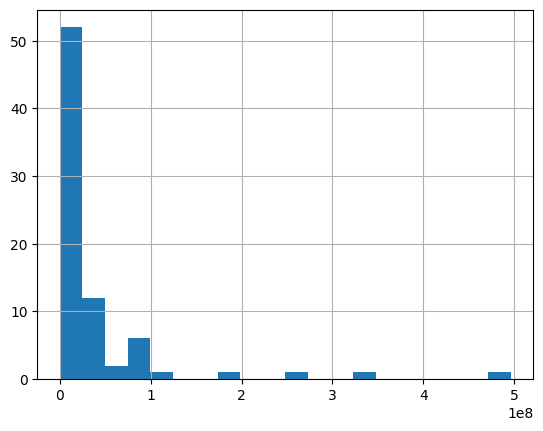

In [19]:
# Analyzing data to determine if it is skewed. #
print(areas["tif_balance"].describe())
print("skew:", round(areas["tif_balance"].skew(), 2))
areas["tif_balance"].hist(bins=20)

In [20]:
import numpy as np

# Time for analysis! Creating a new evaluation index, z-score, which evaluates how a neighborhood compares to the average of all Chicago neighborhoods. #
areas["need_z"] = (areas["hardship_index"] - areas["hardship_index"].mean()) / areas["hardship_index"].std()

# After careful analysis, it has been determined the data is skewed. To account for this, the money is scaled down in order to make outlier neighborhoods less influential. #
log_money = np.log1p(areas["tif_balance"])
areas["money_z"] = (log_money - log_money.mean()) / log_money.std()

# When a neighborhood has high need and low money they are under-resourced. When a neighborhood has low need and high money they are over-resourced. #
areas["mismatch"] = areas["need_z"] - areas["money_z"]

# Ranking focuses on neighborhoods with above-average need to ensure an "under-resourced" classification stays accurate. #
under_resourced = areas[areas["need_z"] > 0].sort_values("mismatch", ascending=False)
under_resourced[["community", "hardship_index", "tif_balance", "mismatch"]].head(10)

,community,hardship_index,tif_balance,mismatch
53,RIVERDALE,98.0,1.082088e+06,2.190981
62,GAGE PARK,93.0,1.008031e+06,2.036274
36,FULLER PARK,97.0,6.428390e+06,1.664368
65,CHICAGO LAWN,80.0,1.181003e+06,1.539456
29,SOUTH LAWNDALE,96.0,2.294062e+07,1.278410
66,WEST ENGLEWOOD,89.0,9.766499e+06,1.270105
67,ENGLEWOOD,94.0,2.677888e+07,1.166005
57,BRIGHTON PARK,84.0,8.934234e+06,1.120413
46,BURNSIDE,79.0,5.718637e+06,1.069273
25,WEST GARFIELD PARK,92.0,3.370025e+07,1.032849


In [21]:
# Data visualization time! #
export = areas.copy()

# Modifying the presentation of geographical data to ensure seamless integration with Power BI's mapping features. #
centroids = export.geometry.to_crs(3435).centroid.to_crs(4326)
export["lat"] = centroids.y
export["lon"] = centroids.x

# keep the columns the dashboard needs (drop geometry — a CSV can't hold shapes)
# Excluding data fields incompatible with Microsoft Excel while preserving columns critical to the dashboard's design. #
cols = ["community", "area_number", "hardship_index", "percent_households_below_poverty",
        "per_capita_income", "tif_increment", "tif_balance",
        "need_z", "money_z", "mismatch", "lat", "lon"]
export[cols].to_csv("Outputs/Chicago Educational Analysis.csv", index=False)

print("saved to Outputs/Chicago Educational Analysis.csv")
export[cols].head()

saved to Outputs/Chicago Educational Analysis.csv


,community,area_number,hardship_index,percent_households_below_poverty,per_capita_income,tif_increment,tif_balance,need_z,money_z,mismatch,lat,lon
0,ROGERS PARK,1,39.0,23.6,23939,3.808922e+06,1.395179e+07,-0.366200,0.204858,-0.571059,42.009623,-87.670167
1,WEST RIDGE,2,46.0,17.2,23040,3.445768e+06,8.163124e+06,-0.122218,0.056936,-0.179154,42.001571,-87.695013
2,UPTOWN,3,20.0,24.0,35787,3.159627e+07,6.874738e+07,-1.028439,0.645008,-1.673447,41.965812,-87.655879
3,LINCOLN SQUARE,4,17.0,10.9,37524,1.104269e+06,3.654762e+06,-1.133003,-0.164844,-0.968159,41.975171,-87.687516
4,NORTH CENTER,5,6.0,7.5,57123,3.563645e+06,9.752359e+06,-1.516405,0.106029,-1.622433,41.947792,-87.683835


In [22]:
import duckdb

duckdb.sql("""
    SELECT community, hardship_index, tif_balance, mismatch
    FROM 'Outputs/Chicago Educational Analysis.csv'
    WHERE need_z > 0
    ORDER BY mismatch DESC
    LIMIT 10
""")

┌────────────────────┬────────────────┬────────────────────┬────────────────────┐
│     community      │ hardship_index │    tif_balance     │      mismatch      │
│      varchar       │     double     │       double       │       double       │
├────────────────────┼────────────────┼────────────────────┼────────────────────┤
│ RIVERDALE          │           98.0 │ 1082087.9302343705 │   2.19098125970258 │
│ GAGE PARK          │           93.0 │ 1008030.5529328984 │ 2.0362735205252904 │
│ FULLER PARK        │           97.0 │  6428389.623308088 │   1.66436837014221 │
│ CHICAGO LAWN       │           80.0 │  1181003.350720912 │ 1.5394562039711492 │
│ SOUTH LAWNDALE     │           96.0 │ 22940617.957646884 │ 1.2784100170512422 │
│ WEST ENGLEWOOD     │           89.0 │  9766499.309973646 │  1.270104750771655 │
│ ENGLEWOOD          │           94.0 │  26778879.66774869 │ 1.1660045914609607 │
│ BRIGHTON PARK      │           84.0 │   8934234.06184606 │ 1.1204126942244361 │
│ BURNSIDE      

In [23]:
duckdb.sql("""
    SELECT
        CASE WHEN hardship_index >= 66 THEN 'High need (66-100)'
             WHEN hardship_index >= 33 THEN 'Medium need (33-65)'
             ELSE 'Low need (0-32)' END AS need_tier,
        COUNT(*) AS neighborhoods,
        ROUND(SUM(tif_balance)/1e6, 0) AS tif_millions,
        ROUND(100.0 * SUM(tif_balance) / (SELECT SUM(tif_balance)
              FROM 'Outputs/Chicago Educational Analysis.csv'), 1) AS pct_of_all_tif
    FROM 'Outputs/Chicago Educational Analysis.csv'
    GROUP BY need_tier
    ORDER BY MIN(hardship_index)
""")

┌─────────────────────┬───────────────┬──────────────┬────────────────┐
│      need_tier      │ neighborhoods │ tif_millions │ pct_of_all_tif │
│       varchar       │     int64     │    double    │     double     │
├─────────────────────┼───────────────┼──────────────┼────────────────┤
│ Low need (0-32)     │            25 │       1590.0 │           53.5 │
│ Medium need (33-65) │            26 │        504.0 │           16.9 │
│ High need (66-100)  │            26 │        880.0 │           29.6 │
└─────────────────────┴───────────────┴──────────────┴────────────────┘

In [24]:
duckdb.sql("""
    -- If Chicago declared a $712M TIF surplus and CPS received its usual 55% share, how would that be distributed? If allocated that specific pool to high-need neighborhoods based strictly on their level of need, here is what each would receive.
    WITH high_need AS (
        SELECT community, hardship_index, tif_balance
        FROM 'Outputs/Chicago Educational Analysis.csv'
        WHERE need_z > 0
    )
    SELECT
        community,
        hardship_index,
        ROUND(tif_balance/1e6, 1) AS current_tif_M,
        ROUND(712 * 0.55 * hardship_index / SUM(hardship_index) OVER (), 1) AS extra_from_surplus_M
    FROM high_need
    ORDER BY extra_from_surplus_M DESC
    LIMIT 10
""")

┌────────────────────┬────────────────┬───────────────┬──────────────────────┐
│     community      │ hardship_index │ current_tif_M │ extra_from_surplus_M │
│      varchar       │     double     │    double     │        double        │
├────────────────────┼────────────────┼───────────────┼──────────────────────┤
│ RIVERDALE          │           98.0 │           1.1 │                 13.3 │
│ FULLER PARK        │           97.0 │           6.4 │                 13.2 │
│ SOUTH LAWNDALE     │           96.0 │          22.9 │                 13.0 │
│ ENGLEWOOD          │           94.0 │          26.8 │                 12.8 │
│ GAGE PARK          │           93.0 │           1.0 │                 12.6 │
│ WEST GARFIELD PARK │           92.0 │          33.7 │                 12.5 │
│ NEW CITY           │           91.0 │          45.1 │                 12.4 │
│ WEST ENGLEWOOD     │           89.0 │           9.8 │                 12.1 │
│ WASHINGTON PARK    │           88.0 │          22.